In [1]:
%reload_ext autoreload
%autoreload 2

# Forecasting Module Demo
Пример использования Forecaster c dummy-моделями.

In [2]:
import sys
sys.path.append("..")

In [3]:
import pandas as pd
import numpy as np
from multi_item_forecaster import MultiItemForecaster
from utils.plot import plot_forecast, df_to_markdown

df = pd.read_csv(r'C:\Users\makanov.artem\Desktop\ВР\imto_ts\tmp\df.csv', index_col=0)

num_exog_cols = [
    'month',
    'wday',
    'year',
    'CASHBACK'
]

cat_exog_cols = [
    'event_name_1',
    'event_type_1',
    'event_name_2',
    'event_type_2',
]
exog_cols = num_exog_cols + cat_exog_cols

df = df[['item_id', 'date', 'cnt'] + exog_cols]

for col in cat_exog_cols:
    df[col] = (~df[col].isna()).astype(np.int32)    

holiday_cols = [
    'event_name_1',
    'event_name_2',
    'CASHBACK'
]

In [4]:
horizon = 14
last_k_days = 28

In [22]:
item_id = 'STORE_1_046'
horizon = 20
exog = df[df.item_id == item_id]
exog = exog.iloc[-horizon:]
exog = exog[exog_cols]
multi_fc.models[item_id].predict(horizon=horizon, exog=exog)

array([4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4.,
       4., 4., 4.])

In [ ]:
item_id = 'STORE_1_046'
horizon = 20
train = df.iloc[:-horizon]

exog = df[df.item_id == item_id]
exog = exog.iloc[:-horizon]
exog = exog[exog_cols]
multi_fc.models[item_id].fit(train, exog=exog)

In [25]:
multi_fc.models[item_id].model.series

,month,wday,year,CASHBACK,event_name_1,event_type_1,event_name_2,event_type_2,cnt,trend,detrended
0,11,4,2013,0,0,0,0,0,4,4.0,0.0
1,11,5,2013,0,0,0,0,0,1,1.0,0.0
2,11,6,2013,0,1,1,0,0,0,0.0,0.0
3,11,7,2013,0,0,0,0,0,4,4.0,0.0
4,11,1,2013,0,0,0,0,0,1,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
698,10,2,2015,0,0,0,0,0,0,0.0,0.0
699,10,3,2015,0,0,0,0,0,2,2.0,0.0
700,10,4,2015,0,0,0,0,0,0,0.0,0.0
701,10,5,2015,0,0,0,0,0,2,2.0,0.0


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000267 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 36
[LightGBM] [Info] Number of data points in the train set: 787, number of used features: 8
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training be

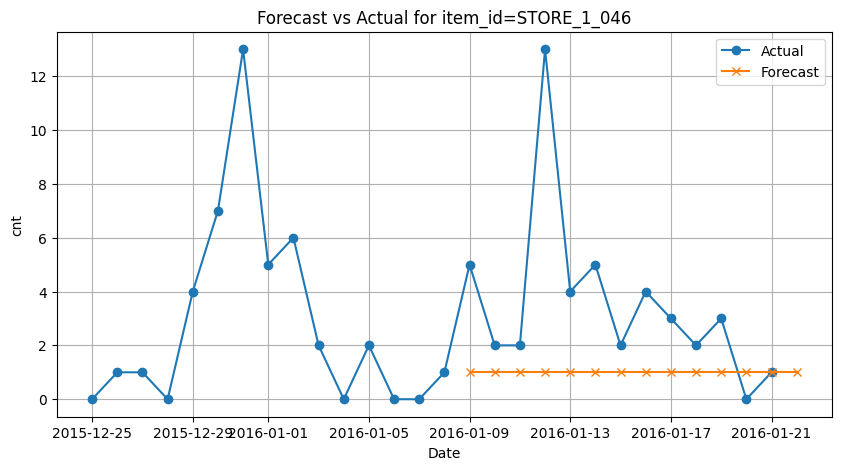

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000612 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 36
[LightGBM] [Info] Number of data points in the train set: 780, number of used features: 8
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training be

,SMAPE,WAPE,RMSE,MASE,MAE,MAPE
7,0.495904,0.568318,6.172874,0.920285,5.185714,1.000000e+08
28,0.836842,0.730459,9.506711,1.417562,8.100000,6.357143e+08
84,0.686086,0.574013,7.288244,1.032443,5.810714,2.011905e+08


In [13]:

multi_fc = MultiItemForecaster(model_name="ml")

# обучаем модель на train
multi_fc.fit(df,exog_cols=exog_cols, lags=[7**k for k in range(4)], trend_window=1)

forecasts = multi_fc.predict(horizon=horizon, test=df, exog_cols=exog_cols)

plot_forecast(df, forecasts, item_id='STORE_1_046', horizon=horizon, last_k_days=last_k_days)

metrics_per_item, metrics_agg = multi_fc.evaluate(df, horizons=[7, 28, 28*3], exog_cols=exog_cols)
pd.DataFrame(metrics_agg).T


In [ ]:

print(df_to_markdown(pd.DataFrame(metrics_agg).T, metrics=['SMAPE', 'WAPE', 'RMSE', 'MASE', 'MAE']))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000621 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 227
[LightGBM] [Info] Number of data points in the train set: 1789, number of used features: 10
[LightGBM] [Info] Start training from score 0.006468
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000367 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 172
[LightGBM] [Info] Number of data points in the train set: 1789, number of used features: 10
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001711 seconds.
Y

,0,1,2,3,4,5
0,SMAPE,WAPE,RMSE,MASE,MAE,MAPE
1,0.913331,123324425.281028,11.578533,1.592815,9.112363,931545167.54382
